In [1]:
import sys
import importlib

sys.path.append("/Users/arthurbenard/Project 1B/src")

import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Force Jupyter to reload the module from the hard drive
import data_converter.hplc_data_handler
importlib.reload(data_converter.hplc_data_handler)

# Now do the specific imports
from data_converter.hplc_data_handler import cleaning_array_by_cas, NMR_SOLVENTS, smiles_to_fingerprint
from controller.predictor_runner import generate_ml_ready_file

sklearn only speaks "math", therefore SMILES needs to be translated (Morgan Fingerprint that acts as barcode)
created smiles_to_fingerprints in hplc_data_handler

we'll first clean the smiles file + raw data, removing duplicates and 0 signals

In [2]:
csv_file = '/Users/arthurbenard/Project 1B/data/Fichier final (RT+sol)_with_smiles.csv'
df_csv = pd.read_csv(csv_file)


excel_file = '/Users/arthurbenard/Project 1B/data/Fichier final (RT+sol)_with_smiles.xlsx'
df_csv.to_excel(excel_file, index=False)

cleaned_df=cleaning_array_by_cas('/Users/arthurbenard/Project 1B/data/Fichier final (RT+sol)_with_smiles.xlsx', cas_column_name='CAS ')

Original Row Count: 1057
Unique Molecules (by CAS): 144
Redundant Rows Deleted: 906
No Signal Rows Deleted: 913
----------------------------------



solvents also need to be converted to numbers, we'll just get the SMILES and then call the same function smiles_to_fingerprint. the df generated below is only for one solvent given, that way its size is approximately 4 x ~150

In [5]:
ml_df = generate_ml_ready_file(cleaned_df, 'MeOH', NMR_SOLVENTS, smiles_to_fingerprint)

[12:08:29] DEPRECATION WARNING: please use MorganGenerator
[12:08:29] DEPRECATION WARNING: please use MorganGenerator
[12:08:29] DEPRECATION WARNING: please use MorganGenerator
[12:08:29] DEPRECATION WARNING: please use MorganGenerator
[12:08:29] DEPRECATION WARNING: please use MorganGenerator
[12:08:29] DEPRECATION WARNING: please use MorganGenerator
[12:08:29] DEPRECATION WARNING: please use MorganGenerator
[12:08:29] DEPRECATION WARNING: please use MorganGenerator
[12:08:29] DEPRECATION WARNING: please use MorganGenerator
[12:08:29] DEPRECATION WARNING: please use MorganGenerator
[12:08:29] DEPRECATION WARNING: please use MorganGenerator
[12:08:29] DEPRECATION WARNING: please use MorganGenerator
[12:08:29] DEPRECATION WARNING: please use MorganGenerator
[12:08:29] DEPRECATION WARNING: please use MorganGenerator
[12:08:29] DEPRECATION WARNING: please use MorganGenerator
[12:08:29] DEPRECATION WARNING: please use MorganGenerator
[12:08:29] DEPRECATION WARNING: please use MorganGenerat

these are commands to verify it worked

In [6]:
print(ml_df.head())
print(f"\nShape: {ml_df.shape}")

                                  Sample Fingerprint     RT  \
0  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  5.607   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  1.146   
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  4.021   
3  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  3.327   
4  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  5.678   

                                             Solvent  Soluble  
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...        1  
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...        0  
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...        0  
3  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...        0  
4  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...        0  

Shape: (144, 4)


let's write a simple model, the **baseline model**. RandomForest is recommended for its ability to handle high dimensions perfectly (our fingerprints generated a lot of 'bits', more rows than columns), handle non-linear data. it is also apparently less prone to overfitting. a good combination of high accuracy, resistance to overfitting, and the ability to easily explain your results. plus we don't have a lot of data... i think it's good to start with this, even though i've read that it isn't very efficient when it comes to predict outside of "what it's seen"

In [5]:
if 'RT' in X.columns:
    X_simple = X.drop(columns=['RT'])
else:
    X_simple = X.copy()

print(f"Baseline Matrix Shape: {X_simple.shape} (Should be exactly 4096 columns of pure chemistry)")

# 70% Train, 20% Val, 10% Test splitting
# Slice off 30% for Val/Test
X_train, X_temp, y_train, y_temp = train_test_split(X_simple, y, test_size=0.30, random_state=42)

# Split the 30% into Validation (2/3 of 30% = 20%) and Test (1/3 of 30% = 10%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=(1/3), random_state=42)

print(f"Training Set:   {X_train.shape[0]} experiments (70%)")
print(f"Validation Set: {X_val.shape[0]} experiments (20%)")
print(f"Testing Set:    {X_test.shape[0]} experiments (10%)\n")

Baseline Matrix Shape: (755, 4096) (Should be exactly 4096 columns of pure chemistry)
Training Set:   528 experiments (70%)
Validation Set: 151 experiments (20%)
Testing Set:    76 experiments (10%)



this is the training cell for **Baseline Model**

In [6]:
# training the Baseline Random Forest ONLY on the training Set
print("Training the Baseline Model ...")
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1,class_weight='balanced')
rf_baseline.fit(X_train, y_train)

Training the Baseline Model ...


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Validation step for **Baseline Model**, printing out results too

In [7]:
predictions_val = rf_baseline.predict(X_val)

print("\n==============================================")
print("  BASELINE MODEL EXAM RESULTS (VALIDATION SET)")
print("==============================================")
print(classification_report(y_val, predictions_val)) #this will give an idea of the accuracy


  BASELINE MODEL EXAM RESULTS (VALIDATION SET)
              precision    recall  f1-score   support

           0       0.89      0.51      0.65        63
           1       0.73      0.95      0.83        88

    accuracy                           0.77       151
   macro avg       0.81      0.73      0.74       151
weighted avg       0.80      0.77      0.75       151



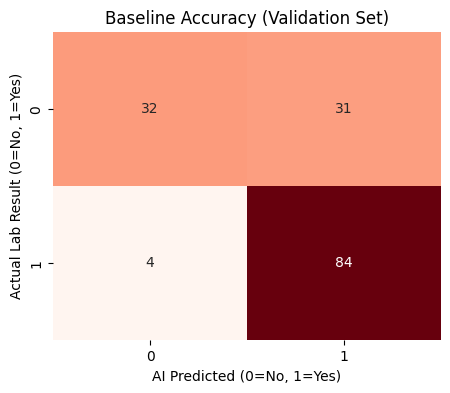

In [8]:
# 6. Plot the Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_val, predictions_val), annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('Baseline Accuracy (Validation Set)')
plt.xlabel('AI Predicted (0=No, 1=Yes)')
plt.ylabel('Actual Lab Result (0=No, 1=Yes)')
plt.show()